In [20]:
# Este comando descarga el repositorio entero a una carpeta llamada 'TFMDS' en Colab.
#!git clone https://github.com/jmorala/TFMDS.git

# Inicializar directorios
Clonar repositorio github
Posicionarse en el directorio raíz

In [21]:
import os

# Detectar si estamos en Google Colab
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# Configurar el directorio de trabajo según el entorno
if IN_COLAB:
    os.chdir('TFMDS')
else:
    # Detectar si estamos en Codespaces o VS Code local
    if os.path.exists('/workspaces/TFMDS'):
        # Entorno Codespaces
        os.chdir('/workspaces/TFMDS')
    else:
        # En VS Code local, nos movemos al directorio raíz del proyecto
        # Usa raw string para evitar errores de escape en rutas Windows
        current_dir = r'C:\Users\jmora\Documents\TFMDS'
        os.chdir(current_dir)

# OPCIONAL: Para verificar que estás en la ruta correcta y ver las carpetas
print("Directorio de trabajo actual:", os.getcwd())

Directorio de trabajo actual: C:\Users\jmora\Documents\TFMDS


In [22]:
# IMPORTS BÁSICOS
import os, sys
import pandas as pd
import numpy as np
import time

# Frameworks de deep learning y NeuralForecast
import torch
import pytorch_lightning as pl
from neuralforecast import NeuralForecast, __version__ as nf_version
# Importar GRU directamente (disponible en la versión instalada)
from neuralforecast.models import GRU
from neuralforecast.losses.pytorch import MAE

# Importar utilidades desde la carpeta 'lib' evitando el paquete
lib_dir = os.path.join(os.getcwd(), 'lib')
if lib_dir not in sys.path:
    sys.path.insert(0, lib_dir)

from lib.dl_utils import (
    preparar_datos_neuralforecast,
    seleccionar_features_exogenas,
    reconstruir_predicciones,
    preparar_variables_estaticas,
)
from lib.metricas import calcular_metricas, comparar_metricas, resumen_metricas, agregar_estadisticas_error, resumen_final_modelos
from lib.graficos_dl import (
    grafico_prediccion_diaria_agregada,
    grafico_prediccion_por_cluster,
    grafico_productos_por_cluster,
    dashboard_metricas_dl,
    dashboard_prediccion_dl
)

print(f"torch: {torch.__version__}")
print(f"pytorch_lightning: {pl.__version__}")
print(f"neuralforecast: {nf_version}")
print("GRU disponible en neuralforecast.models: ", GRU is not None)


torch: 2.9.1+cpu
pytorch_lightning: 2.5.0
neuralforecast: 1.6.4
GRU disponible en neuralforecast.models:  True


In [23]:
# ============================================================================
# LECTURA DE DATOS
# ============================================================================

print("\n" + "="*100)
print("📂 CARGANDO DATOS PARA DEEP LEARNING")
print("="*100)

# Datos normalizados para entrenamiento
df_train_raw = pd.read_csv('datos/df_train_dl.csv', sep=';', parse_dates=['idSecuencia'])
df_test_raw = pd.read_csv('datos/df_test_dl.csv', sep=';', parse_dates=['idSecuencia'])

print(f"\nDatos cargados:")
print(f"\nColumnas: {list(df_train_raw.columns)}")
print(f"   Train: {df_train_raw.shape}")
print(f"   Test:  {df_test_raw.shape}")


📂 CARGANDO DATOS PARA DEEP LEARNING

Datos cargados:

Columnas: ['idSecuencia', 'producto', 'udsVenta', 'bolPromocion', 'bolOpen', 'bolHoliday', 'lag_ventas_1', 'lag_ventas_2', 'lag_ventas_3', 'lag_ventas_4', 'lag_ventas_5', 'lag_ventas_6', 'lag_ventas_7', 'EWMA_corto', 'EWMA_largo', 'Tendencia_EWMA', 'dia_semana_sin', 'dia_semana_cos', 'mes_sin', 'mes_cos', 'semana_sin', 'semana_cos', 'Cluster_0', 'Cluster_1', 'Cluster_2', 'Cluster_3']
   Train: (625800, 26)
   Test:  (27714, 26)


# Preparación de datos para NeuralForecast

In [24]:
# ============================================================================
# PREPARACIÓN DE DATOS PARA NEURALFORECAST
# ============================================================================

print("\n" + "="*100)
print("🔧 PREPARANDO DATOS PARA NEURALFORECAST")
print("="*100)

# Convertir al formato NeuralForecast (unique_id, ds, y)
df_train_nf, df_test_nf = preparar_datos_neuralforecast(
    df_train_raw,
    df_test_raw,
    col_fecha='idSecuencia',
    col_producto='producto',
    col_target='udsVenta'
)

print(f"\n📋 Columnas: {list(df_train_nf.columns)}")
print(f"   Train: {df_train_nf.shape}")
print(f"   Test:  {df_test_nf.shape}")


🔧 PREPARANDO DATOS PARA NEURALFORECAST

📋 Columnas: ['ds', 'unique_id', 'y', 'bolPromocion', 'bolOpen', 'bolHoliday', 'lag_ventas_1', 'lag_ventas_2', 'lag_ventas_3', 'lag_ventas_4', 'lag_ventas_5', 'lag_ventas_6', 'lag_ventas_7', 'EWMA_corto', 'EWMA_largo', 'Tendencia_EWMA', 'dia_semana_sin', 'dia_semana_cos', 'mes_sin', 'mes_cos', 'semana_sin', 'semana_cos', 'Cluster_0', 'Cluster_1', 'Cluster_2', 'Cluster_3']
   Train: (625800, 26)
   Test:  (27714, 26)


# Configuración del modelo GRU

El algoritmo Gated Recurrent Unit (GRU) es una **variante simplificada y menos compleja** de las redes gru. Fue desarrollado para capturar **dependencias temporales a largo plazo** y mitigar el **problema del gradiente desvanecido**. Las redes GRU generalmente resultan **significativamente más rápidas de entrenar** que las LSTM.

La arquitectura GRU se distingue porque **no utiliza el estado de la célula (cell state)**. En su lugar, gestiona el flujo de información usando **solo el estado oculto**, empleando principalmente **dos compuertas**: la **compuerta de actualización** (*update gate*) y la **compuerta de reinicio** (*reset gate*). La compuerta de actualización determina **cuánta información pasada debe transmitirse**, mientras que la compuerta de reinicio decide **cuánta información debe olvidarse**.

Para su implementación, la arquitectura GRU requiere que los datos de entrada se reestructuren en un **tensor 3D**. Además, necesita que se defina e inicialice un **estado oculto inicial ($h_0$)**, que a menudo se establece en cero. Para la predicción final, se utiliza la **salida del último paso de tiempo** de la capa GRU.

## Preparar característias estáticas

In [25]:
# ============================================================================
# PREPARAR VARIABLES ESTÁTICAS
# ============================================================================

print("\n" + "="*100)
print("🔧 PREPARANDO VARIABLES ESTÁTICAS")
print("="*100)

# Definir columnas estáticas (que no varían en el tiempo)
stat_exog_list = ['Cluster_0', 'Cluster_1', 'Cluster_2', 'Cluster_3']

# Separar variables estáticas en DataFrame aparte
df_train_nf, df_test_nf, static_df = preparar_variables_estaticas(
    df_train_nf,
    df_test_nf,
    stat_exog_list
)

print(f"\n📋 Columnas df_train_nf: {list(df_train_nf.columns)}")


🔧 PREPARANDO VARIABLES ESTÁTICAS

✅ Variables estáticas extraídas:
   Columnas estáticas: ['Cluster_0', 'Cluster_1', 'Cluster_2', 'Cluster_3']
   Shape static_df: (894, 5)
   Productos únicos: 894

📊 Datasets temporales actualizados:
   Train: (625800, 22) (eliminadas 4 columnas)
   Test:  (27714, 22) (eliminadas 4 columnas)

📋 Columnas df_train_nf: ['ds', 'unique_id', 'y', 'bolPromocion', 'bolOpen', 'bolHoliday', 'lag_ventas_1', 'lag_ventas_2', 'lag_ventas_3', 'lag_ventas_4', 'lag_ventas_5', 'lag_ventas_6', 'lag_ventas_7', 'EWMA_corto', 'EWMA_largo', 'Tendencia_EWMA', 'dia_semana_sin', 'dia_semana_cos', 'mes_sin', 'mes_cos', 'semana_sin', 'semana_cos']


## Preparar características históricas

In [26]:
# =============================================================================
# LIMPIEZA DE FEATURES HISTÓRICAS (evitar NaN al inicio del test)
# =============================================================================

print("\n" + "="*100)
print("🧹 LIMPIANDO FEATURES HISTÓRICAS (hist_exog_list)")
print("="*100)

# Definir la lista de features históricas que usa el modelo
hist_exog_list = [
    'lag_ventas_1', 'lag_ventas_2', 'lag_ventas_3', 'lag_ventas_4',
    'lag_ventas_5', 'lag_ventas_6', 'lag_ventas_7',
    'EWMA_corto', 'EWMA_largo', 'Tendencia_EWMA'
]

# Comprobar existencia de columnas
def _check_missing(df, cols):
    return [c for c in cols if c not in df.columns]

missing_train = _check_missing(df_train_nf, hist_exog_list)
missing_test = _check_missing(df_test_nf, hist_exog_list)

if missing_train:
    print(f"⚠️ Faltan columnas en train: {missing_train}")
if missing_test:
    print(f"⚠️ Faltan columnas en test: {missing_test}")

cols_ok = [c for c in hist_exog_list if c in df_train_nf.columns and c in df_test_nf.columns]

if cols_ok:
    # Estadísticas antes
    na_train_before = int(df_train_nf[cols_ok].isna().sum().sum())
    na_test_before = int(df_test_nf[cols_ok].isna().sum().sum())

    # Forward fill por serie (unique_id) y rellenar remanentes al inicio con 0
    df_train_nf[cols_ok] = (
        df_train_nf.groupby('unique_id', observed=True)[cols_ok]
        .ffill()
        .fillna(0)
    )
    df_test_nf[cols_ok] = (
        df_test_nf.groupby('unique_id', observed=True)[cols_ok]
        .ffill()
        .fillna(0)
    )

    # Asegurar tipos numéricos (por si hubiera strings)
    for df_tmp in (df_train_nf, df_test_nf):
        for c in cols_ok:
            df_tmp[c] = pd.to_numeric(df_tmp[c], errors='coerce').fillna(0)

    # Estadísticas después
    na_train_after = int(df_train_nf[cols_ok].isna().sum().sum())
    na_test_after = int(df_test_nf[cols_ok].isna().sum().sum())

    print(f"✅ NaNs en train: {na_train_before} → {na_train_after}")
    print(f"✅ NaNs en test:  {na_test_before} → {na_test_after}")
else:
    print("⚠️ No hay columnas históricas válidas para limpiar.")

print("\n" + "="*100)
print(f"Features históricas {hist_exog_list}")


🧹 LIMPIANDO FEATURES HISTÓRICAS (hist_exog_list)
✅ NaNs en train: 3 → 0
✅ NaNs en test:  0 → 0

Features históricas ['lag_ventas_1', 'lag_ventas_2', 'lag_ventas_3', 'lag_ventas_4', 'lag_ventas_5', 'lag_ventas_6', 'lag_ventas_7', 'EWMA_corto', 'EWMA_largo', 'Tendencia_EWMA']


## Preparar características futuras

In [27]:
# FEATURES FUTURAS

futr_exog_list=[
        'bolOpen', 'bolHoliday', 'bolPromocion',
        'dia_semana_sin', 'dia_semana_cos',
        'mes_sin', 'mes_cos',
        'semana_sin', 'semana_cos'
    ]

print("\n" + "="*100)
print(f"Features futuras {futr_exog_list}")


Features futuras ['bolOpen', 'bolHoliday', 'bolPromocion', 'dia_semana_sin', 'dia_semana_cos', 'mes_sin', 'mes_cos', 'semana_sin', 'semana_cos']


## Configuración del modelo

In [ ]:
# CONFIGURACIÓN DEL MODELO GRU (ajusta hiperparámetros según necesidades)
HORIZON = 31
modelo_gru = GRU(
    h=HORIZON,
    input_size=60,
    loss=MAE(),
    max_steps=1500,
    encoder_hidden_size=128,
    encoder_n_layers=2,
    decoder_hidden_size=128,
    decoder_layers=2,
    learning_rate=1e-3,
    scaler_type='standard',
    batch_size=32,
    random_seed=42,
    futr_exog_list=futr_exog_list
    hist_exog_list=hist_exog_list,
    stat_exog_list=stat_exog_list,
    enable_progress_bar=True
)
print('Modelo GRU configurado: ', modelo_gru)

Seed set to 42


Modelo GRU configurado:  GRU


# Entrenamiento del modelo

In [29]:
# ============================================================================
# ENTRENAMIENTO DEL MODELO
# ============================================================================

print("\n" + "="*100)
print("🚀 INICIANDO ENTRENAMIENTO GRU")
print("="*100)

# Crear instancia de NeuralForecast
nf = NeuralForecast(
    models=[modelo_gru],
    freq='D'  # Frecuencia diaria
)

# Entrenar el modelo
print("\n⏳ Entrenando modelo GRU...")
start_time = time.perf_counter()

nf.fit(df=df_train_nf, static_df=static_df)

elapsed = time.perf_counter() - start_time
print(f"\n✅ Entrenamiento completado en {elapsed:.2f} segundos ({elapsed/60:.2f} minutos)")


🚀 INICIANDO ENTRENAMIENTO GRU

⏳ Entrenando modelo GRU...


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]


✅ Entrenamiento completado en 290.98 segundos (4.85 minutos)


# GRU Global

In [30]:
# ============================================================================
# PREDICCIÓN
# ============================================================================

print("\n" + "="*100)
print("🔮 GENERANDO PREDICCIONES")
print("="*100)

# Realizar predicciones
print("\n⏳ Generando predicciones en test set...")
start_time = time.perf_counter()

y_hat = nf.predict(futr_df=df_test_nf)

elapsed = time.perf_counter() - start_time

print(f"\n✅ Predicciones generadas en {elapsed:.2f} segundos")
print(f"   Shape predicciones: {y_hat.shape}")
print(f"\n📋 Primeras predicciones:")
print(y_hat.head())


🔮 GENERANDO PREDICCIONES

⏳ Generando predicciones en test set...


Predicting: |          | 0/? [00:00<?, ?it/s]


✅ Predicciones generadas en 15.88 segundos
   Shape predicciones: (27714, 2)

📋 Primeras predicciones:
                  ds       GRU
unique_id                     
1         2024-10-06  0.269800
1         2024-10-07  8.219921
1         2024-10-08  7.670186
1         2024-10-09  8.386580
1         2024-10-10  8.306731


# Reconstruir predicciones en formato original

In [31]:
def preparar_predicciones_test(y_hat, df_test_nf):
    """
    Prepara las predicciones en formato NeuralForecast para métricas y gráficos.
    
    Parameters
    ----------
    y_hat : pd.DataFrame
        DataFrame con predicciones del modelo. Debe contener 'unique_id', 'ds' 
        y columna de predicción (ej: 'GRU', 'prediccion', etc.)
    df_test_nf : pd.DataFrame
        DataFrame de test en formato NeuralForecast con columnas 'unique_id', 
        'ds', 'y', 'bolOpen'
    
    Returns
    -------
    pd.DataFrame
        Dataset con predicciones procesadas, incluyendo errores calculados
    """
    print("\n" + "="*100)
    print("🔧 PREPARANDO PREDICCIONES PARA MÉTRICAS Y GRÁFICOS")
    print("="*100)
    
    # y_hat puede venir con 'unique_id' como índice; normalizamos para merge
    if y_hat.index.name == 'unique_id':
        y_hat = y_hat.reset_index()
    
    # Asegurar que existen columnas necesarias
    required_cols_pred = {'unique_id', 'ds'}
    if not required_cols_pred.issubset(set(y_hat.columns)):
        raise ValueError(f"Faltan columnas en y_hat para merge: {required_cols_pred - set(y_hat.columns)}")
    
    # Renombrar columna del modelo a 'prediccion' sin copiar innecesariamente
    if 'GRU' in y_hat.columns:
        y_hat = y_hat.rename(columns={'GRU': 'prediccion'})
    elif 'prediccion' not in y_hat.columns:
        # Si el modelo cambió el nombre, tomamos la primera columna de predicción distinta a ['unique_id','ds']
        pred_cols = [c for c in y_hat.columns if c not in ['unique_id', 'ds']]
        if not pred_cols:
            raise ValueError("No se encontró columna de predicción en y_hat.")
        y_hat = y_hat.rename(columns={pred_cols[0]: 'prediccion'})
    
    # Merge con el test en formato NF (evitando copias)
    df_test_pred = df_test_nf[['unique_id', 'ds', 'y', 'bolOpen']].merge(
        y_hat[['unique_id', 'ds', 'prediccion']],
        on=['unique_id', 'ds'],
        how='left'
    )
    
    # Columnas compatibles con funciones de gráficos existentes
    df_test_pred['idSecuencia'] = df_test_pred['ds']
    df_test_pred['producto'] = df_test_pred['unique_id']
    # Mantener convención 'udsVenta' para métricas existentes
    df_test_pred['udsVenta'] = df_test_pred['y']
    
    # Si df_test_pred la columna prediccion es menor que cero pone un cero
    df_test_pred['prediccion'] = df_test_pred['prediccion'].clip(lower=0)
    
    # Eliminar días que la tienda está cerrada
    df_test_pred = df_test_pred[df_test_pred['bolOpen'] == 1].copy()
    
    # Calcular errores en escala original
    df_test_pred['error'] = df_test_pred['prediccion'] - df_test_pred['udsVenta']
    df_test_pred['error_abs'] = np.abs(df_test_pred['error'])
    
    # print(f"\n✅ Dataset de predicciones listo (sin reconstrucción ni desnormalización):")
    # print(f"   Shape: {df_test_pred.shape}")
    # print(f"   Predicciones no nulas: {df_test_pred['prediccion'].notna().sum()}")
    # print(f"\n📊 Estadísticas básicas del error (escala original):")
    # print(f"   Error medio: {df_test_pred['error'].mean():.2f} unidades")
    # print(f"   Error std: {df_test_pred['error'].std():.2f} unidades")
    # print(f"   Error abs medio: {df_test_pred['error_abs'].mean():.2f} unidades")
    
    return df_test_pred

In [32]:
df_test_pred = preparar_predicciones_test (y_hat, df_test_nf)


🔧 PREPARANDO PREDICCIONES PARA MÉTRICAS Y GRÁFICOS


# Reconstruir columna Cluster desde one-hot encoding

In [33]:
# ============================================================================
# RECONSTRUIR COLUMNA CLUSTER DESDE static_df (one-hot estático)
# ============================================================================

# Si ya existe 'Cluster' en el dataset de predicciones, la respetamos
if 'Cluster' in df_test_pred.columns:
    try:
        df_test_pred['Cluster'] = df_test_pred['Cluster'].astype('Int64')
    except Exception:
        pass
    print("\n✅ Columna 'Cluster' ya presente en df_test_pred.")
    print("   Distribución:")
    print(df_test_pred['Cluster'].value_counts(dropna=False).sort_index())
else:
    # Intentar reconstruir desde static_df (variables estáticas por unique_id)
    cluster_cols = [c for c in static_df.columns if c.startswith('Cluster_')]

    if cluster_cols:
        # Ordenar columnas y calcular argmax por unique_id
        cluster_cols = sorted(cluster_cols, key=lambda x: int(x.split('_')[1]))
        static_map = static_df[['unique_id'] + cluster_cols].copy()
        cluster_idx = static_map[cluster_cols].to_numpy().argmax(axis=1)
        static_map['Cluster'] = cluster_idx

        # Unir al dataset de predicciones
        df_test_pred = df_test_pred.merge(
            static_map[['unique_id', 'Cluster']],
            on='unique_id',
            how='left'
        )

        print(f"\n✅ 'Cluster' reconstruido desde static_df ({len(cluster_cols)} columnas one-hot).")
        print("   Distribución:")
        print(df_test_pred['Cluster'].value_counts(dropna=False).sort_index())
    else:
        print("\n⚠️ No se encontraron columnas 'Cluster_*' en static_df.")
        print("   Las visualizaciones por cluster no estarán disponibles.")


✅ 'Cluster' reconstruido desde static_df (4 columnas one-hot).
   Distribución:
Cluster
0     7826
1     2756
2      416
3    12246
Name: count, dtype: int64


# Métricas y gráficos GRU Global

## Métricas

In [34]:
from lib.utils import obtener_top_productos_por_cluster

# ============================================================================
# CÁLCULO DE MÉTRICAS
# ============================================================================

print("\n" + "="*100)
print("📊 CÁLCULO DE MÉTRICAS")
print("="*100)

# Filtrar valores válidos (sin NaN)
df_valid = df_test_pred.dropna(subset=['prediccion', 'udsVenta'])

# Calcular métricas
metricas_gru = calcular_metricas(
    y=df_valid['udsVenta'],
    y_pred=df_valid['prediccion'],
    algoritmo='GRU',
    ndetalle= 'Global',
    cluster=None,
    producto=None
)

# Mostrar resumen
print("\n📊 Métricas del Modelo Global:")
resumen_metricas([metricas_gru])

# Guardar para comparación posterior
todas_metricas = [metricas_gru]

# Calcular métricas por cluster y guardar
for cluster in df_test_pred['Cluster'].unique():
    y_test_pred_cl = df_test_pred.loc[df_test_pred['Cluster'] == cluster, ['prediccion']]
    y_test_cl = df_test_pred.loc[df_test_pred['Cluster'] == cluster, ['udsVenta']]
    metricas_cluster = calcular_metricas(
        y_test_cl, y_test_pred_cl,
        algoritmo='GRU', ndetalle='Global', cluster= cluster, producto=None)
    todas_metricas.append(metricas_cluster)
    
# Construir columna Cluster en df_train_raw si no existe
if 'Cluster' not in df_train_raw.columns:
    if cluster_cols:
        cluster_idx_train = static_df[cluster_cols].to_numpy().argmax(axis=1)
        static_map_train = static_df[['unique_id']].copy()
        static_map_train['Cluster'] = cluster_idx_train
        df_train_raw = df_train_raw.merge(
            static_map_train[['unique_id', 'Cluster']],
            left_on='producto',
            right_on='unique_id',
            how='left'
        )
        df_train_raw.drop(columns=['unique_id'], inplace=True)
        print("\n✅ 'Cluster' añadido a df_train_raw desde static_df.")
    else:
        print("\n⚠️ No se pudo añadir 'Cluster' a df_train_raw (faltan columnas one-hot).")
    
# Calcular métricas por producto top en cada cluster
top_productos = obtener_top_productos_por_cluster(
    df=df_train_raw,
    col_ventas='udsVenta',
    col_cluster='Cluster',
    col_producto='producto',
    n_productos=2
)

for cluster, productos in top_productos.items():
    for producto in productos:
        idx_producto = (df_test_pred['Cluster'] == cluster) & (df_test_pred['producto'] == producto)
        y_test_prod = df_test_pred.loc[idx_producto, 'udsVenta']
        y_test_pred_prod = df_test_pred.loc[idx_producto, 'prediccion']
        metricas_producto = calcular_metricas(
            y_test_prod, y_test_pred_prod,
            algoritmo='GRU',
            ndetalle='Global', cluster=cluster, producto=producto) 
        todas_metricas.append(metricas_producto)

resumen_metricas(todas_metricas)    


📊 CÁLCULO DE MÉTRICAS

📊 Métricas del Modelo Global:

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle Cluster Producto    MAE   RMSE     R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
      GRU   Global    None     None 1.4099 2.6097 0.1113     73.03     162.71 0.7998    86.35

🏆 Mejor modelo: GRU (RMSE: 2.6097)

✅ 'Cluster' añadido a df_train_raw desde static_df.

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle  Cluster  Producto    MAE    RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
      GRU   Global      3.0     314.0 0.0226  0.0313  0.0000       NaN     200.00    NaN      NaN
      GRU   Global      3.0     257.0 0.5156  1.2391 -0.1570     98.66     198.69 0.8431   103.12
      gru   Global      3.0       NaN 0.8085  1.8962 -0.2048     95.56     195.69 0.8509    99.55
      GRU   Global      0.0     413.0 1.6801  2.2844 -0.0782     53.01     124.12 0.7997    80.89
      GRU   Global      NaN       NaN 1.4099  2.6097  0.1113     73.03     162.71 0.7998    86.35
      GRU   Global      0.0     294

## Dashboard

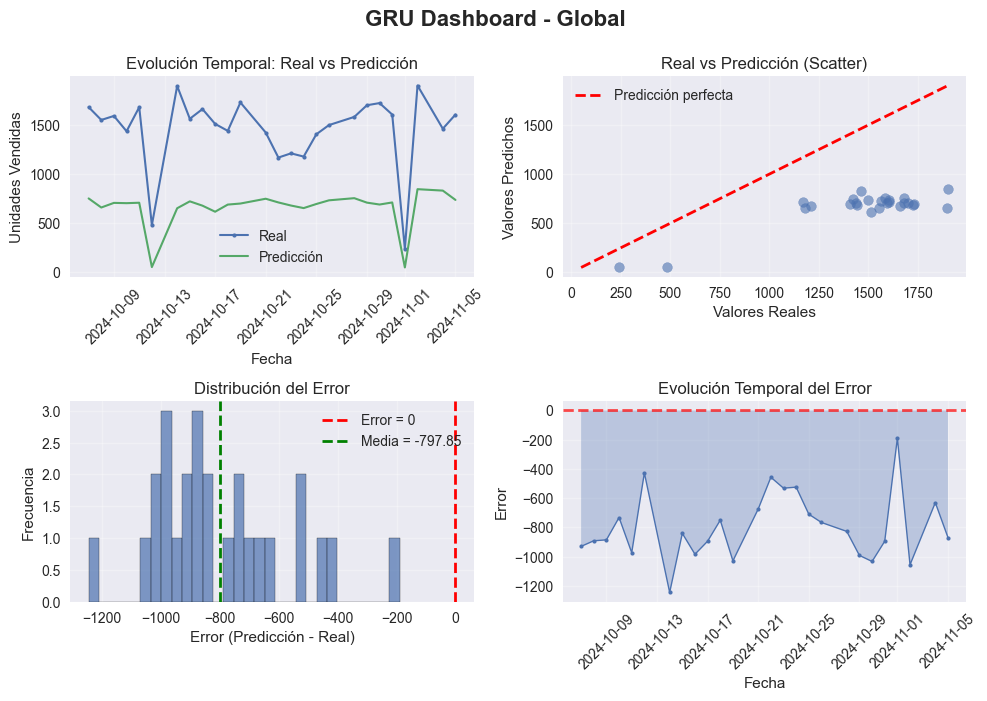

In [35]:
# Visualizaciones del modelo global
df_test_viz_sum = df_test_pred.groupby('idSecuencia')[['udsVenta', 'prediccion']].sum().reset_index()
df_test_viz_sum['error'] = df_test_viz_sum['prediccion'] - df_test_viz_sum['udsVenta']

dashboard_prediccion_dl(
        df=df_test_viz_sum,
        col_fecha='idSecuencia',
        col_real='udsVenta',
        col_pred='prediccion',
        titulo_principal=f'GRU Dashboard - Global',
        figsize=(10, 7)
        )

# GRU por Cluster

Procesando Cluster_0:
  - df_train_nf_c: 210700 filas
  - df_test_nf_c: 9331 filas

⏳ Entrenando modelo GRU...


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]


✅ Entrenamiento completado en 296.33 segundos (4.94 minutos)

⏳ Generando predicciones en test set...


Predicting: |          | 0/? [00:00<?, ?it/s]


✅ Predicciones generadas en 5.71 segundos

🔧 PREPARANDO PREDICCIONES PARA MÉTRICAS Y GRÁFICOS

📊 Métricas del Modelo para Cluster_0:

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle  Cluster Producto    MAE   RMSE     R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
      GRU  Cluster        0     None 1.7417 2.7212 -0.006     50.05     137.87 0.7822    90.21

🏆 Mejor modelo: GRU (RMSE: 2.7212)


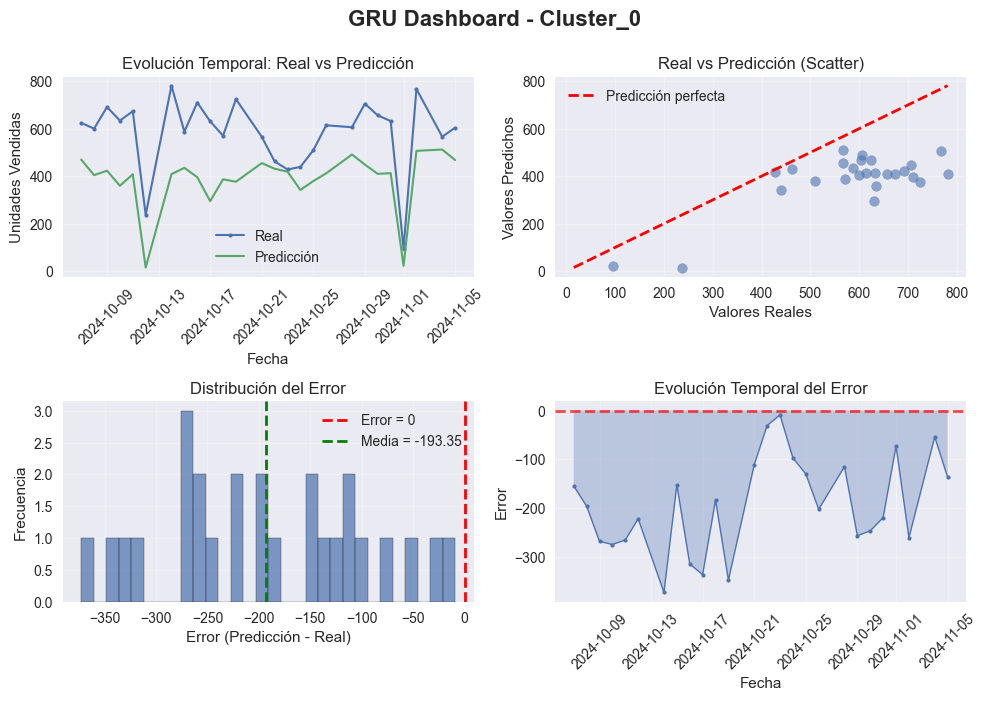

Procesando Cluster_1:
  - df_train_nf_c: 74200 filas
  - df_test_nf_c: 3286 filas

⏳ Entrenando modelo GRU...


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]


✅ Entrenamiento completado en 292.06 segundos (4.87 minutos)

⏳ Generando predicciones en test set...


Predicting: |          | 0/? [00:00<?, ?it/s]


✅ Predicciones generadas en 2.29 segundos

🔧 PREPARANDO PREDICCIONES PARA MÉTRICAS Y GRÁFICOS

📊 Métricas del Modelo para Cluster_1:

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle  Cluster Producto    MAE   RMSE     R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
      GRU  Cluster        1     None 2.7695 3.8193 0.0298     52.53     103.72 0.7633    72.63

🏆 Mejor modelo: GRU (RMSE: 3.8193)


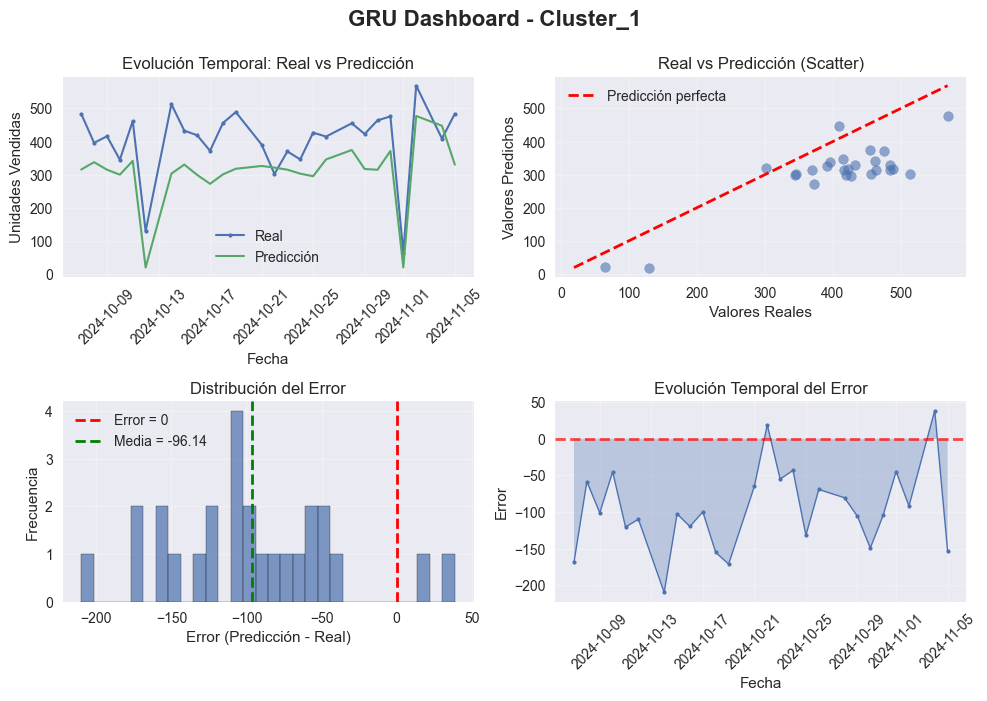

Procesando Cluster_2:
  - df_train_nf_c: 11200 filas
  - df_test_nf_c: 496 filas

⏳ Entrenando modelo GRU...


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]


✅ Entrenamiento completado en 318.35 segundos (5.31 minutos)

⏳ Generando predicciones en test set...


Predicting: |          | 0/? [00:00<?, ?it/s]


✅ Predicciones generadas en 1.10 segundos

🔧 PREPARANDO PREDICCIONES PARA MÉTRICAS Y GRÁFICOS

📊 Métricas del Modelo para Cluster_2:

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle  Cluster Producto    MAE   RMSE     R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
      GRU  Cluster        2     None 3.8757 5.6099 0.0275      77.5      82.67 0.7801    67.49

🏆 Mejor modelo: GRU (RMSE: 5.6099)


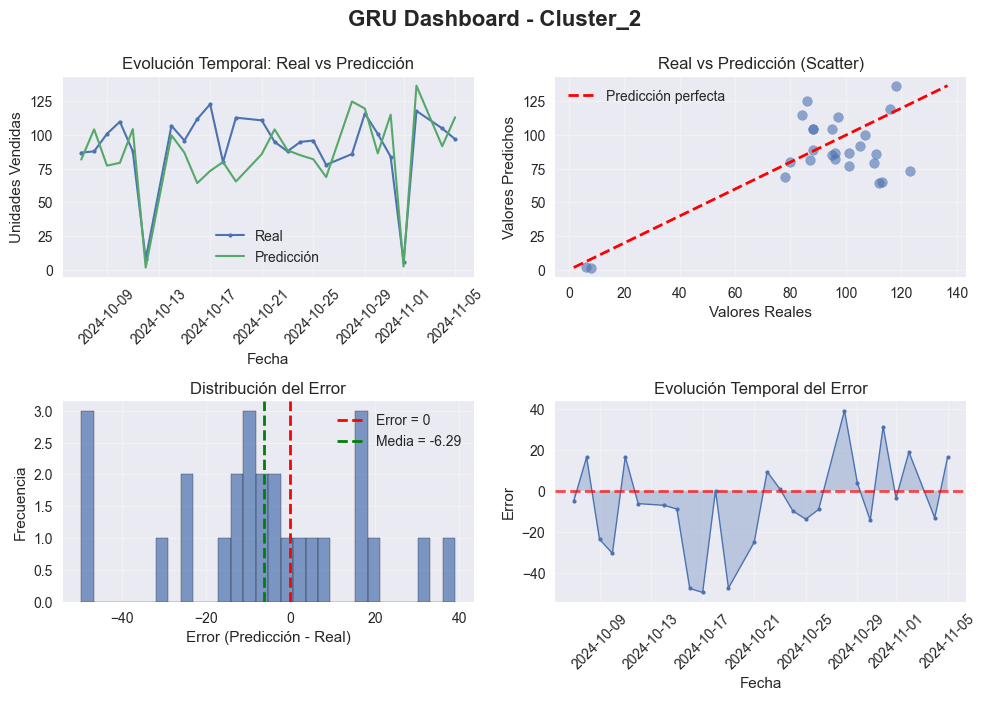

Procesando Cluster_3:
  - df_train_nf_c: 329700 filas
  - df_test_nf_c: 14601 filas

⏳ Entrenando modelo GRU...


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]


✅ Entrenamiento completado en 370.57 segundos (6.18 minutos)

⏳ Generando predicciones en test set...


Predicting: |          | 0/? [00:00<?, ?it/s]


✅ Predicciones generadas en 9.67 segundos

🔧 PREPARANDO PREDICCIONES PARA MÉTRICAS Y GRÁFICOS

📊 Métricas del Modelo para Cluster_3:

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle  Cluster Producto    MAE   RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
      GRU  Cluster        3     None 0.8059 1.8976 -0.2066     95.74     195.01 0.8515    99.23

🏆 Mejor modelo: GRU (RMSE: 1.8976)


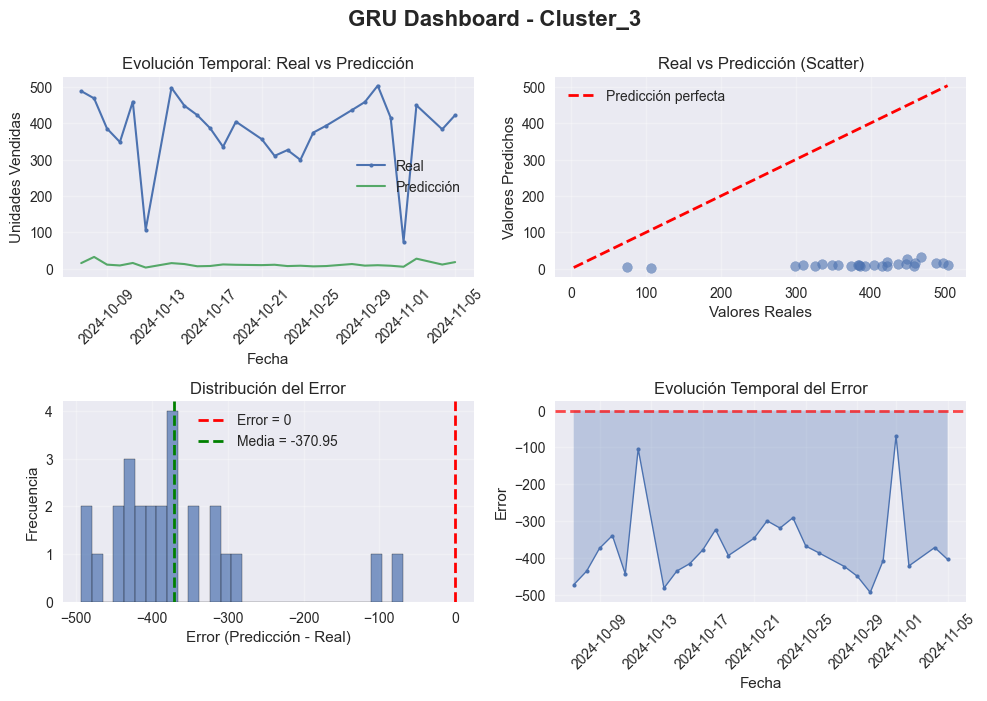

In [36]:
# Obtener las columnas que comienzan con 'Cluster_'
cluster_cols = [col for col in df_train_raw.columns if col.startswith('Cluster_')]

# Iterar sobre cada columna de cluster
for cluster_col in cluster_cols:
    # Filtrar df_test_nf usando la máscara de df_test_raw
    mask_test = df_test_raw[cluster_col] == 1
    df_test_nf_c = df_test_nf[mask_test]
    
    # Filtrar df_train_nf usando la máscara de df_train_raw
    mask_train = df_train_raw[cluster_col] == 1
    df_train_nf_c = df_train_nf[mask_train]
    
    # Aquí puedes trabajar con df_test_nf_c y df_train_nf_c
    print(f"Procesando {cluster_col}:")
    print(f"  - df_train_nf_c: {len(df_train_nf_c)} filas")
    print(f"  - df_test_nf_c: {len(df_test_nf_c)} filas")

    # Entrenar el modelo
    print("\n⏳ Entrenando modelo GRU...")
    start_time = time.perf_counter()
    nf.fit(df=df_train_nf_c, static_df=static_df)
    elapsed = time.perf_counter() - start_time
    print(f"\n✅ Entrenamiento completado en {elapsed:.2f} segundos ({elapsed/60:.2f} minutos)")

    # Realizar predicciones
    print("\n⏳ Generando predicciones en test set...")
    start_time = time.perf_counter()
    y_hat = nf.predict(futr_df=df_test_nf_c)
    elapsed = time.perf_counter() - start_time
    print(f"\n✅ Predicciones generadas en {elapsed:.2f} segundos")

    df_test_pred = preparar_predicciones_test (y_hat, df_test_nf_c)

    # Calcular métricas por cluster y guardar
    df_valid = df_test_pred.dropna(subset=['prediccion', 'udsVenta'])
    cluster=int(cluster_col.split('_')[-1])
    # Calcular métricas
    metricas_gru = calcular_metricas(
        y=df_valid['udsVenta'],
        y_pred=df_valid['prediccion'],
        algoritmo='GRU',
        ndetalle= 'Cluster',
        cluster=cluster,
        producto=None
    )

    # Mostrar resumen
    print(f"\n📊 Métricas del Modelo para {cluster_col}:")
    resumen_metricas([metricas_gru])

    todas_metricas.append(metricas_gru)
    
    df_test_viz_sum = df_test_pred.groupby('idSecuencia')[['udsVenta', 'prediccion']].sum().reset_index()
    df_test_viz_sum['error'] = df_test_viz_sum['prediccion'] - df_test_viz_sum['udsVenta']

    dashboard_prediccion_dl(
            df=df_test_viz_sum,
            col_fecha='idSecuencia',
            col_real='udsVenta',
            col_pred='prediccion',
            titulo_principal=f'GRU Dashboard - {cluster_col}',
            figsize=(10, 7)
            )
    
    for producto in top_productos.get(cluster, []):
        idx_producto = (df_test_pred['producto'] == producto)
        y_test_prod = df_test_pred.loc[idx_producto, 'udsVenta']
        y_test_pred_prod = df_test_pred.loc[idx_producto, 'prediccion']
        metricas_producto = calcular_metricas(
            y_test_prod, y_test_pred_prod,
            algoritmo='GRU',
            ndetalle='Cluster', cluster=int(cluster_col.split('_')[-1]), producto=producto)
        todas_metricas.append(metricas_producto)

# Resumen de métricas

In [37]:
# Ejecutar el resumen final usando la función de la librería
resumen_final_modelos(todas_metricas)


🏆 RESUMEN FINAL - COMPARACIÓN DE TODOS LOS MODELOS

📊 Resumen de todas las métricas (todas las columnas):
Algoritmo NDetalle  Cluster  Producto    MAE      MSE    RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
      GRU  Cluster      3.0     314.0 0.0319   0.0025  0.0504  0.0000       NaN     200.00    NaN      NaN
      GRU  Cluster      3.0     257.0 0.5002   1.5449  1.2429 -0.1642     99.23     198.99 0.8457   100.04
      GRU  Cluster      3.0       NaN 0.8059   3.6008  1.8976 -0.2066     95.74     195.01 0.8515    99.23
      GRU  Cluster      0.0     413.0 1.5829   4.3275  2.0803  0.1059     31.42     101.22 0.7282    76.21
      GRU  Cluster      0.0       NaN 1.7417   7.4047  2.7212 -0.0060     50.05     137.87 0.7822    90.21
      GRU  Cluster      0.0     294.0 1.9971   7.7538  2.7846  0.0279     34.26     128.82 0.6415   108.18
      GRU  Cluster      1.0       NaN 2.7695  14.5871  3.8193  0.0298     52.53     103.72 0.7633    72.63
      GRU  Cluster      2.0       2.0

# Guardar resultados

In [38]:
# ============================================================================
# GUARDAR RESULTADOS DE MÉTRICAS
# ============================================================================

print("\n" + "="*100)
print("💾 GUARDANDO RESULTADOS")
print("="*100)

# salvar resultados en fichero
df_resultados = pd.DataFrame(todas_metricas)
df_resultados.to_csv('datos/resultados_metricas_GRU.csv', index=False)


💾 GUARDANDO RESULTADOS
